# TEXAS — Google Colab Quickstart

**TEXAS** (`texas-psm`) is a Bayesian proxy system model for TEX<sub>86</sub> paleothermometry.

This notebook walks through:
1. Installing CmdStan and the package
2. Downloading the pre-computed posteriors from Zenodo
3. **Forward prediction** — temperature → Scaled RI (pure Python, no Stan)
4. **Inverse reconstruction** — Scaled RI → temperature with full uncertainty (runs Stan)

---

> **Saving your work**: This notebook runs on a temporary Colab session. To keep your edits, go to **File → Save a copy in Drive** before making changes.

> **What requires Stan?**
> | Task | Stan needed? |
> |------|-------------|
> | `predict_proxy_from_T()` — plot calibration curve | ❌ No |
> | `predict_T_from_proxyObs()` — reconstruct paleotemperature | ✅ Yes |
> | `get_posterior()` — re-fit the calibration from scratch | ✅ Yes |

---

### Step 1a — Install CmdStan on Google Colab

In [1]:
# # ── Step 1a: Install CmdStan ───────────────────────────────────────────────────
# # Required before importing TEXAS. Skip this cell only if you need forward
# # prediction (predict_proxy_from_T) and NOT inverse reconstruction.
# # Takes ~5–10 minutes. Must be re-run each new Colab session.
# !pip install -q cmdstanpy
# import cmdstanpy
# cmdstanpy.install_cmdstan(version="2.36.0", progress=True)
# print(f"✅ CmdStan ready: {cmdstanpy.cmdstan_path()}")

### Step 1b — Install TEXAS

In [2]:
# # ── Step 1b: Install TEXAS ─────────────────────────────────────────────────────
# !pip install -q texas-psm

In [3]:
import os

import numpy as np
import xarray as xr
import pandas as pd

import TEXAS
print(f"TEXAS version: {TEXAS.__version__}")

TEXAS version: 0.2.6


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/plotting/residual_maps.py:57: UserWarning: `natural_earth_v5_0_0.ocean_basins_50` does not quite extend to 180°E - it's recommended to use `natural_earth_v5_1_2.ocean_basins_50` instead. See https://github.com/regionmask/regionmask/issues/410.
  _OCEAN_BASINS_50 = regionmask.defined_regions.natural_earth_v5_0_0.ocean_basins_50


---

## Step 2 — Mount Google Drive (optional)

Mount your Drive if your proxy data or posteriors are stored there.
Skip this cell if you plan to upload files directly or use the Zenodo download below.

In [4]:
# from google.colab import drive
# drive.mount("/content/drive")

# # Set a base path for your data on Drive — change to your folder:
# DRIVE_BASE = "/content/drive/MyDrive/texas"

# import os
# os.makedirs(DRIVE_BASE, exist_ok=True)
# print(f"Drive mounted. Working folder: {DRIVE_BASE}")

---

## Step 3 — Download the pre-computed posteriors

The forward calibration posteriors (`.nc` files) are required for both forward
and inverse predictions. Download them once from Zenodo — they are cached for
the session. If you mounted Google Drive above, point the cache there so you
don't re-download every session.



In [5]:
import os
import TEXAS

# ── Nothing to download for the default calibration ───────────────────────────
# The full multivariate T0-shift calibration (tx.GHEB.sst.sri03.G23-N1p0) and its
# thermocline counterpart ship inside the package, so a reconstruction runs on a
# bare `pip install texas-psm` with no network access.

# ── Option A: cache downloads on Google Drive (survives session restarts) ─────
# Uncomment after mounting Drive in Step 2:
# os.environ["TEXAS_CACHE_DIR"] = f"{DRIVE_BASE}/posteriors"

# ── Option B: cache in ephemeral Colab storage (re-downloaded each session) ────
# Nothing to set — default cache is used automatically.

# ── Any OTHER calibration is fetched once from Zenodo and cached ──────────────
TEXAS.download_posteriors([
    "tx.GHPU.sst.sri03.p0",          # temperature-only, used in Example 1 below
])

# TEXAS.download_all()               # everything in the record (~158 MB)

# What you have now — bundled and downloaded alike
TEXAS.list_posteriors("forward")

All requested posteriors already cached.
Forward calibration posteriors  [/home/rrattan/Documents/GitHub/TEXAS/data/cache/TEXAS_posterior_cache]
  gen_logi_fixed_culmeso_cultureT_scaledRI_cren3
  gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3
  gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_thermoT_gdgt23ratio_no3_1.0_scaledRI_cren3
  gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3
  gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_scaledRI_cren3
  tx.GCDU.cul.sri.p0.fwd
  tx.GCDU.cul.sri03.p0.fwd
  tx.GCDU.cul.sri05.p0.fwd
  tx.GHEA.sst.sri.G23-N1p0.fwd
  tx.GHEA.sst.sri.G23.fwd
  tx.GHEA.sst.sri.N1p0.fwd
  tx.GHEA.sst.sri03.G23-N1p0.fwd
  tx.GHEA.sst.sri03.G23.fwd
  tx.GHEA.sst.sri03.N1p0.fwd
  tx.GHEA.sst.sri05.G23-N1p0.fwd
  tx.GHEA.thm.sri.G23-N1p0.fwd
  tx.GHEA.thm.sri.G23.fwd
  tx.GHEA.thm.sri.N1p0.fwd
  tx.GHEA.thm.sri03.G23-N1p0.fwd
  tx.GHEA.thm.sri03.G23.fwd
  tx.GHEA.thm.sri03.N1p0.fwd
  tx.GHEB.sst.sri.G23-N1p0.fwd
  t

{'forward': ['gen_logi_fixed_culmeso_cultureT_scaledRI_cren3',
  'gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3',
  'gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_thermoT_gdgt23ratio_no3_1.0_scaledRI_cren3',
  'gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3',
  'gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_scaledRI_cren3',
  'tx.GCDU.cul.sri.p0.fwd',
  'tx.GCDU.cul.sri03.p0.fwd',
  'tx.GCDU.cul.sri05.p0.fwd',
  'tx.GHEA.sst.sri.G23-N1p0.fwd',
  'tx.GHEA.sst.sri.G23.fwd',
  'tx.GHEA.sst.sri.N1p0.fwd',
  'tx.GHEA.sst.sri03.G23-N1p0.fwd',
  'tx.GHEA.sst.sri03.G23.fwd',
  'tx.GHEA.sst.sri03.N1p0.fwd',
  'tx.GHEA.sst.sri05.G23-N1p0.fwd',
  'tx.GHEA.thm.sri.G23-N1p0.fwd',
  'tx.GHEA.thm.sri.G23.fwd',
  'tx.GHEA.thm.sri.N1p0.fwd',
  'tx.GHEA.thm.sri03.G23-N1p0.fwd',
  'tx.GHEA.thm.sri03.G23.fwd',
  'tx.GHEA.thm.sri03.N1p0.fwd',
  'tx.GHEB.sst.sri.G23-N1p0.fwd',
  'tx.GHEB.sst.sri03.G23-N1p0.fwd',
  'tx.GHEB.sst.sri03.G23.fwd',
  't

### How posterior files are named

Posteriors use CESM-style **case ids** — fixed dot-delimited positions:

```
tx . GHEB . sst . sri03 . G23-N1p0 . fwd.nc
│    │      │     │       │         └ role: fwd = forward calibration; inv.<site> = a reconstruction
│    │      │     │       └ predictors: G23, N1p0 (NO₃, cutoff 1.0 — `p` is the decimal point), or p0 = none
│    │      │     └ proxy: sri03 = scaledRI_cren3, sri = scaledRI, tex = TEX86
│    │      └ target temperature: sst, thm (Thermo-T), cul (culture T)
│    └ compset: curve (G/L/N) · training set (H/C/J/T) · estimator (P/E/D) ·
│      predictor structure (U univariate, A additive β,
│      B bounded-by-construction = the **T₀-shift** structure, γ)
└ project prefix
```

Every function that takes a posterior name accepts **either** a case id or the
legacy long name (`gen_logi_fixed_...`) that the Zenodo archive's flat files
still carry, and either spelling of the nitrate token (`N1p0` or the older `N10`).

The **published T₀-shift calibration** (`GHEB`, coefficients `gamma_*` in °C per
predictor unit) is the default and ships with the package. The `GHEA` posteriors
on Zenodo are the preprint's response-offset formulation (`beta_*`, in Scaled-RI
units per predictor unit), kept for reproducing that version. You do not have to
choose between them by hand: TEXAS reads which formulation a posterior carries
and selects the matching inverse model.

### Inspect your forward model posteriors of fitted parameters

In [6]:
from TEXAS import load_posterior

# The default calibration — no download needed, it ships with the package.
fname = 'tx.GHEB.sst.sri03.G23-N1p0'

### load_posterior() takes the name only (no ".nc"). It looks in the cache first
### (default data/cache/TEXAS_posterior_cache/, or TEXAS_CACHE_DIR), then falls
### back to the posteriors bundled inside the package.
test_ds = load_posterior(fname)

display(test_ds)

<xarray.Dataset> Size: 97MB
Dimensions:                (chain: 4, draw: 1000,
                            true_gdgt23ratio_crtp_dim_0: 1513,
                            true_no3_crtp_dim_0: 1513)
Coordinates:
  * chain                  (chain) int64 32B 1 2 3 4
  * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
Dimensions without coordinates: true_gdgt23ratio_crtp_dim_0, true_no3_crtp_dim_0
Data variables: (12/14)
    t0_crtp                (chain, draw) float64 32kB 34.88 33.97 ... 35.19
    k_crtp                 (chain, draw) float64 32kB 0.3292 0.2684 ... 0.3058
    b_crtp                 (chain, draw) float64 32kB 0.4168 0.4122 ... 0.4036
    v_crtp                 (chain, draw) float64 32kB 4.555 3.749 ... 4.762
    gamma_G23_crtp         (chain, draw) float64 32kB 0.5563 0.6778 ... 0.6567
    gamma_NO3_crtp         (chain, draw) float64 32kB 2.758 2.509 ... 2.717
    ...                     ...
    true_no3_crtp          (chain, draw, true_no3_crtp_dim_0) float64 48MB 0....
    R2_full                (chain, draw) float64 32kB 0.8132 0.8114 ... 0.8132
    bayesR2_full           (chain, draw) float64 32kB 0.8737 0.8731 ... 0.8689
    RMSE_full              (chain, draw) float64 32kB 0.04942 ... 0.04943
    mu_min                 (chain, draw) float64 32kB 0.4383 0.4324 ... 0.4311
    mu_max                 (chain, draw) float64 32kB 0.8444 0.831 ... 0.8334
Attributes: (12/47)
    stan_version:                 2.36.0
    num_draws_sampling:           1000
    run_time:                     2026-08-12T14:15:16.855296
    run_duration (sec):           118.99
    temptype:                     SST
    N_crtp:                       1513
    ...                           ...
    filename:                     tx.v026.GHEB.sst.sri03.G23-N10.001.fwd.nc
    iter_warmup:                  400
    iter_warmup_source:           asserted from manifest.csv; not recoverable...
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox...
    case_id:                      tx.GHEB.sst.sri03.G23-N1p0
    generated_by:                 texas-psm

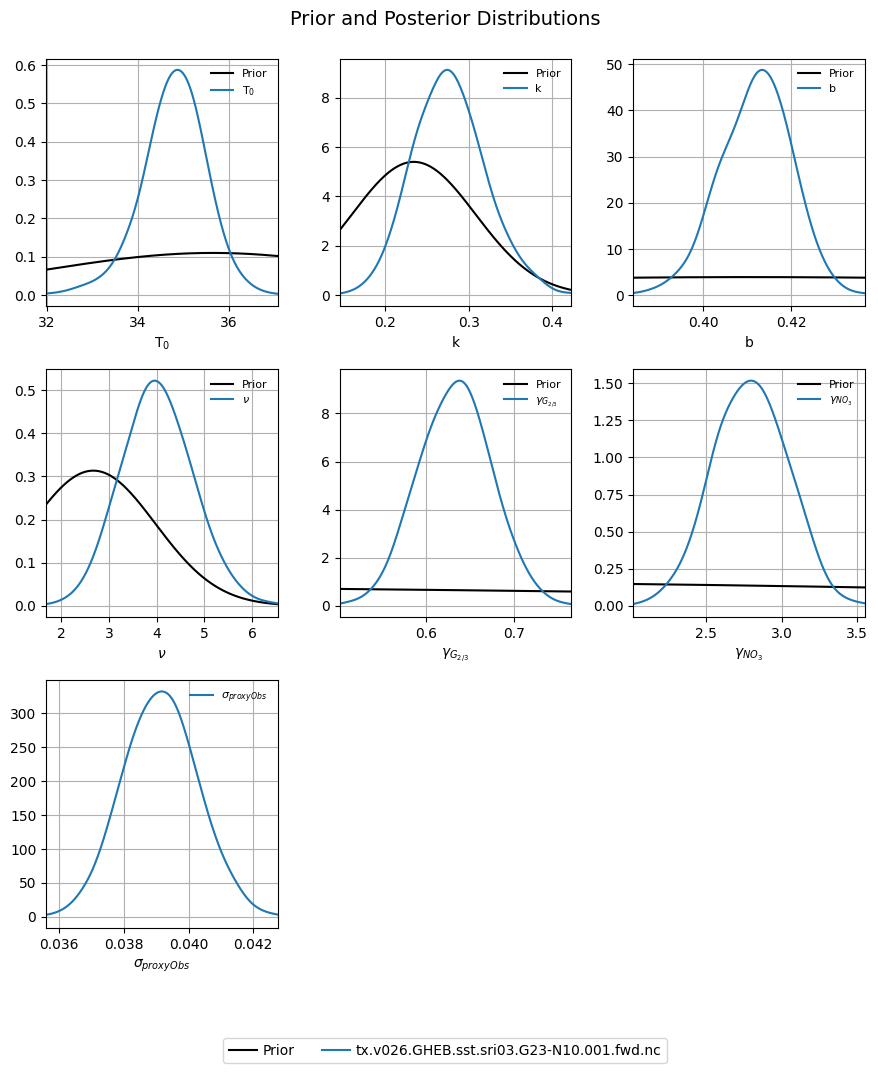

In [7]:
from TEXAS import plot_prior_distributions
fig, axs = plot_prior_distributions(
    priors_list = test_ds.attrs['priors'],
    posterior_datasets=[test_ds],
    show_histogram=False,
    show_prior_expression=False)

---

## Step 4 — Forward prediction: temperature → Scaled RI

`predict_proxy_from_T()` evaluates the calibration curve at a range of
temperatures. **No Stan required** — this is pure Python using the loaded posterior.

Use this to visualise the calibration curve or to generate forward-model
predictions from a temperature ensemble.

### Start with a toy data; simple linspace array

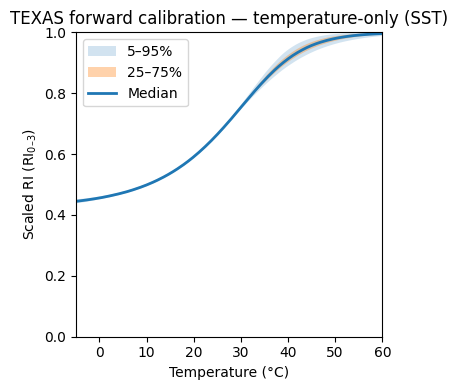

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import ultraplot as plot
import pandas as pd
from TEXAS import predict_proxy_from_T


### In this example, temperatures is a linspace array; an evenly-spaced array of n values between a and b in np.linspace(a,b,n)
temperatures = np.linspace(-5,60, 200)


## Temperature-only posterior (SST, canonical Scaled RI₀₋₃)
## A default value for n_draws is set at 500 --- n_draws is the number of posterior ensemble members used for forward modeling
## The function predict_proxy_from_T() uses each paired-parameters solved from the CmdStan (MCMC) to build an S-curve ensemble
## Percentiles (e.g., "p50") are calculated from the n_draws number of S-curve ensembles generate
## the pre-computed forward model posteriors used in TEXAS have 4000 members (4 chains x 1000 draws per chain)

set_n_draw = 1500 ### The code is default at 5000 if n_draws is not provided in the function signature.
result = predict_proxy_from_T(
    temperatures=temperatures,
    n_draws=set_n_draw,
    posterior="tx.GHPU.sst.sri03.p0",
    percentiles=[5, 25, 50, 75, 95],
)

# Plot calibration curve with uncertainty
fig, ax = plt.subplots(figsize=(4, 4))
ax.fill_between(temperatures, result["p5"],  result["p95"], alpha=0.2,  label="5–95%")
ax.fill_between(temperatures, result["p25"], result["p75"], alpha=0.35, label="25–75%")
ax.plot(temperatures, result["p50"], lw=2, label="Median")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel(u"Scaled RI (RI$_{0\u20133}$)")
ax.set_title("TEXAS forward calibration — temperature-only (SST)")
ax.set_ylim(0,1)
ax.set_xlim(-5,60)
ax.legend()
plt.tight_layout()
plt.show()

---

## Step 5 — Inverse reconstruction: Scaled RI → temperature

`predict_T_from_proxyObs()` reconstructs paleotemperatures from observed
Scaled RI values. **Requires CmdStan** (Step 1b).

> **Recommended pre-processing for real proxy data:**
> 1. Compute Scaled RI and GDGT-2/3 ratio from raw abundances
> 2. **Screen with Mahalanobis distance** to remove samples outside the modern coretop calibration domain
> 3. Run `predict_T_from_proxyObs()` on the screened data
>
> The PETM example in Step 5b below demonstrates this full workflow.

Replace the example data below with your own downcore or coretop Scaled RI
observations.

### Example 1: Toy data - T only

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from TEXAS import predict_T_from_proxyObs

# ── Load your data ─────────────────────────────────────────────────────────────
# Option A — from Google Drive (uncomment after Step 2):
# df = pd.read_csv(f"{DRIVE_BASE}/my_coretop_data.csv")

# Option B — upload interactively:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

# Option C — example synthetic data (replace with your own):
np.random.seed(42)
n = 15
scaledRI_obs = np.random.uniform(0.35, 0.95, n)   # your downcore Scaled RI₀₋₃ values

fwd_post_name = "tx.GHPU.sst.sri03.p0"
# ── Run inverse reconstruction ─────────────────────────────────────────────────
result = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 15.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 10.0,    # prior uncertainty (°C) — use ~10 when uncertain
    fwd_posterior = fwd_post_name,   # a non-default choice: temperature only
)


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/data/builder.py:211: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_available = post.dims[draw_dim_name]
/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:481: RuntimeWarning: Stan model 'invT_gen_logi_fixed_univ_marginal_unconstrained' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
18:27:02 - cmdstanpy - INFO - compiling stan file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_univ_marginal_unconstrained.stan to exe file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_univ_m

⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
🔧 Automatically selected Stan file: invT_gen_logi_fixed_univ_marginal_unconstrained.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=15
🔧 Compiling Stan model: invT_gen_logi_fixed_univ_marginal_unconstrained.stan
   (build dir: /home/rrattan/.texas/stan_cache)


18:27:09 - cmdstanpy - INFO - compiled model executable: /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_univ_marginal_unconstrained
18:27:09 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_univ_marginal_unconstrained.stan
Starting Stan sampling with 15 observations...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

18:27:16 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


In [10]:
## OPTIONAL: This cell repeats the previous cell with larger sigma T input
fwd_post_name = "tx.GHPU.sst.sri03.p0"
result_sigmaT_20 = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 15.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 20.0,    # prior uncertainty (°C) — use ~10 when uncertain
    fwd_posterior = fwd_post_name,   # a non-default choice: temperature only
)

/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/data/builder.py:211: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_available = post.dims[draw_dim_name]
/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:481: RuntimeWarning: Stan model 'invT_gen_logi_fixed_univ_marginal_unconstrained' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
18:27:16 - cmdstanpy - INFO - compiling stan file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_univ_marginal_unconstrained.stan to exe file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_univ_m

⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
🔧 Automatically selected Stan file: invT_gen_logi_fixed_univ_marginal_unconstrained.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=15
🔧 Compiling Stan model: invT_gen_logi_fixed_univ_marginal_unconstrained.stan
   (build dir: /home/rrattan/.texas/stan_cache)


18:27:23 - cmdstanpy - INFO - compiled model executable: /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_univ_marginal_unconstrained
18:27:23 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_univ_marginal_unconstrained.stan
Starting Stan sampling with 15 observations...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

18:27:39 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


#### Output structure of invT model

`predict_T_from_proxyObs()` outputs a result dictionary containing following variables
- `proxyObs` --- this is the input proxy observations (e.g., Scaled RI)
- `proxy_name` --- scaledRI_cren3 is the variable name for "Scaled RI<sub>0--3<\sub>" used in texas-psm model development
- `metadata` --- a dictionary contains input data and stan diagnosis parameters
- `pxx` --- pre-computed percentiles available at p1, p5, p10, p16, p25, p50, p75, p84, p90, p95, p99

In [11]:
# ── Summary table ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    "scaledRI":  scaledRI_obs,
    "T_p5":  result["p5"],
    "T_p25": result["p25"],
    "T_p50": result["p50"],
    "T_p75": result["p75"],
    "T_p95": result["p95"],
})
results_df.round(2).head(10)

,scaledRI,T_p5,T_p25,T_p50,T_p75,T_p95
0,0.57,5.21,12.38,16.63,19.78,23.69
1,0.92,31.97,35.06,37.26,39.97,44.86
2,0.79,25.01,28.32,30.41,32.43,35.66
3,0.71,19.84,23.78,26.03,28.14,31.15
4,0.44,-5.68,2.37,6.88,10.67,15.78
5,0.44,-5.55,1.95,6.59,10.79,15.75
6,0.38,-8.25,-1.18,3.46,7.72,12.76
7,0.87,29.75,32.52,34.55,36.85,40.74
8,0.71,19.64,23.74,26.14,28.45,31.37
9,0.77,24.15,27.39,29.61,31.62,34.75


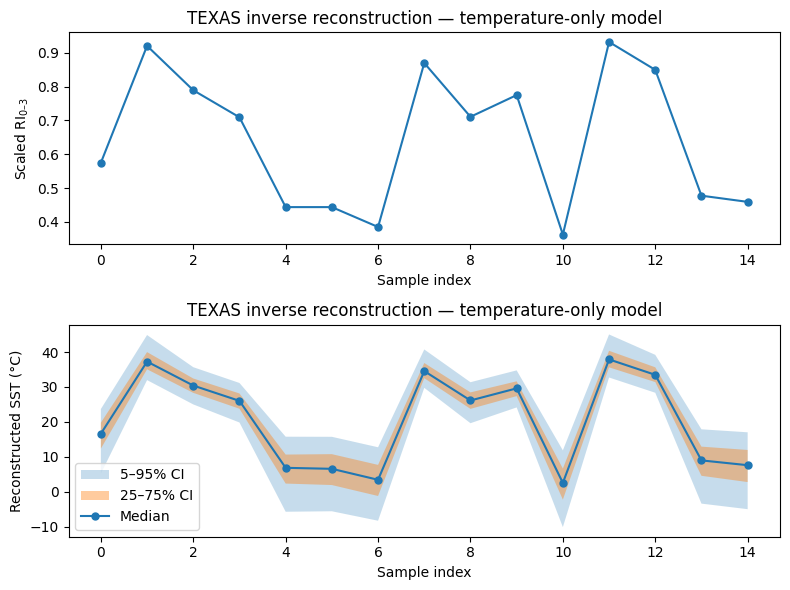

In [12]:
# ── Plot results ───────────────────────────────────────────────────────────────
fig, axs = plt.subplots(figsize=(8, 6),nrows=2,sharey=False)

ax = axs[0]
idx = np.arange(n)
ax.plot(idx, result["proxyObs"], "o-", ms=5, lw=1.5, label="Median")
ax.set_xlabel("Sample index")
ax.set_ylabel(u"Scaled RI$_{0\u20133}$")
ax.set_title("TEXAS inverse reconstruction — temperature-only model")

ax = axs[1]
idx = np.arange(n)
ax.fill_between(idx, result["p5"], result["p95"], alpha=0.25, label="5–95% CI")
ax.fill_between(idx, result["p25"], result["p75"], alpha=0.4, label="25–75% CI")
ax.plot(idx, result["p50"], "o-", ms=5, lw=1.5, label="Median")
ax.set_xlabel("Sample index")
ax.set_ylabel("Reconstructed SST (°C)")
ax.set_title("TEXAS inverse reconstruction — temperature-only model")
ax.legend()
plt.tight_layout()
plt.show()

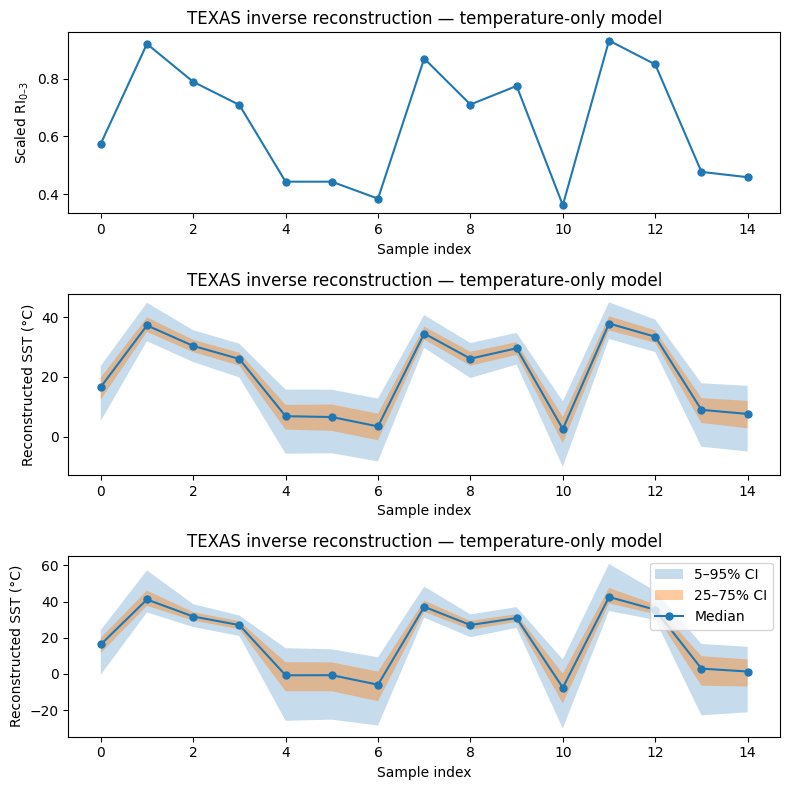

In [13]:
# ── Plot results ───────────────────────────────────────────────────────────────
fig, axs = plt.subplots(figsize=(8, 8),nrows=3,sharey=False)

ax = axs[0]
idx = np.arange(n)
ax.plot(idx, result["proxyObs"], "o-", ms=5, lw=1.5, label="Median")
ax.set_xlabel("Sample index")
ax.set_ylabel(u"Scaled RI$_{0\u20133}$")
ax.set_title("TEXAS inverse reconstruction — temperature-only model")

ax = axs[1]
idx = np.arange(n)
ax.fill_between(idx, result["p5"], result["p95"], alpha=0.25, label="5–95% CI")
ax.fill_between(idx, result["p25"], result["p75"], alpha=0.4, label="25–75% CI")
ax.plot(idx, result["p50"], "o-", ms=5, lw=1.5, label="Median")
ax.set_xlabel("Sample index")
ax.set_ylabel("Reconstructed SST (°C)")
ax.set_title("TEXAS inverse reconstruction — temperature-only model")

ax = axs[2]
idx = np.arange(n)
ax.fill_between(idx, result_sigmaT_20["p5"], result_sigmaT_20["p95"], alpha=0.25, label="5–95% CI")
ax.fill_between(idx, result_sigmaT_20["p25"], result_sigmaT_20["p75"], alpha=0.4, label="25–75% CI")
ax.plot(idx, result_sigmaT_20["p50"], "o-", ms=5, lw=1.5, label="Median")
ax.set_xlabel("Sample index")
ax.set_ylabel("Reconstructed SST (°C)")
ax.set_title("TEXAS inverse reconstruction — temperature-only model")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

#### Example 1b: Toy data -- add G23 and NO3 predictors

In [14]:
np.random.seed(42)

gdgt23ratio_obs = np.full(scaledRI_obs.shape, 15)

# ── Run inverse reconstruction ─────────────────────────────────────────────────
# No fwd_posterior: this uses the default calibration, tx.GHEB.sst.sri03.G23-N1p0
# (full multivariate, G23 + NO3). Pass temptype="thermoT" for the thermocline one.
result2 = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 15.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 10.0,    # prior uncertainty (°C) — use ~10 when uncertain
    gdgt23ratio    = gdgt23ratio_obs,
    no3            = 10,      # above the 1.0 umol/L threshold: NO3 correction off
)

📚 No fwd_posterior given — using the default SST calibration 'tx.GHEB.sst.sri03.G23-N1p0' (full multivariate, G23 + NO3).


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/data/builder.py:211: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_available = post.dims[draw_dim_name]
/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:481: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
18:27:40 - cmdstanpy - INFO - compiling stan file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan to exe file /home/rrattan/.texas/stan_cache/invT_g

⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=15
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
   (build dir: /home/rrattan/.texas/stan_cache)


18:27:48 - cmdstanpy - INFO - compiled model executable: /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift
18:27:48 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
Starting Stan sampling with 15 observations...


...

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

18:28:01 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


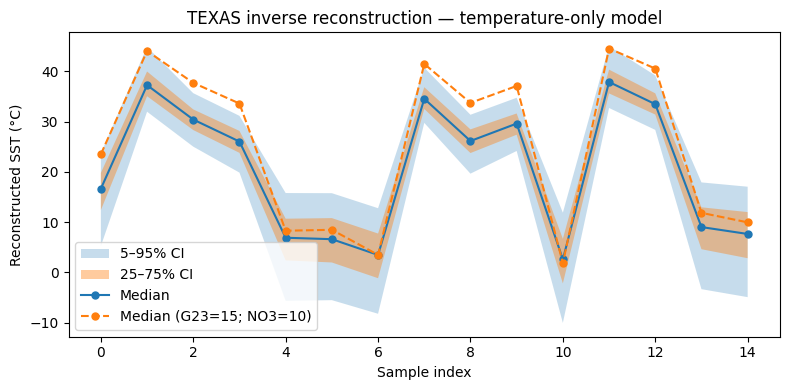

In [15]:
# ── Plot results ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
idx = np.arange(n)
ax.fill_between(idx, result["p5"], result["p95"], alpha=0.25, label="5–95% CI")
ax.fill_between(idx, result["p25"], result["p75"], alpha=0.4, label="25–75% CI")
ax.plot(idx, result["p50"], "o-", ms=5, lw=1.5, label="Median")

ax.plot(idx, result2["p50"], "o--", ms=5, lw=1.5, label="Median (G23=15; NO3=10)")


ax.set_xlabel("Sample index")
ax.set_ylabel("Reconstructed SST (°C)")
ax.set_title("TEXAS inverse reconstruction — temperature-only model")


ax.legend()
plt.tight_layout()
plt.show()

In [16]:
## Now, try to set very low nitrates

# ── Run inverse reconstruction ─────────────────────────────────────────────────
result3 = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 15.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 10.0,    # prior uncertainty (°C) — use ~10 when uncertain
    gdgt23ratio    = gdgt23ratio_obs,
    no3            = 0.01,    # inside (0, 1.0]: the NO3 correction applies
)

📚 No fwd_posterior given — using the default SST calibration 'tx.GHEB.sst.sri03.G23-N1p0' (full multivariate, G23 + NO3).


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/data/builder.py:211: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_available = post.dims[draw_dim_name]
/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:481: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
18:28:02 - cmdstanpy - INFO - compiling stan file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan to exe file /home/rrattan/.texas/stan_cache/invT_g

⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=15
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
   (build dir: /home/rrattan/.texas/stan_cache)


18:28:11 - cmdstanpy - INFO - compiled model executable: /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift
18:28:11 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
Starting Stan sampling with 15 observations...


...

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

18:28:26 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


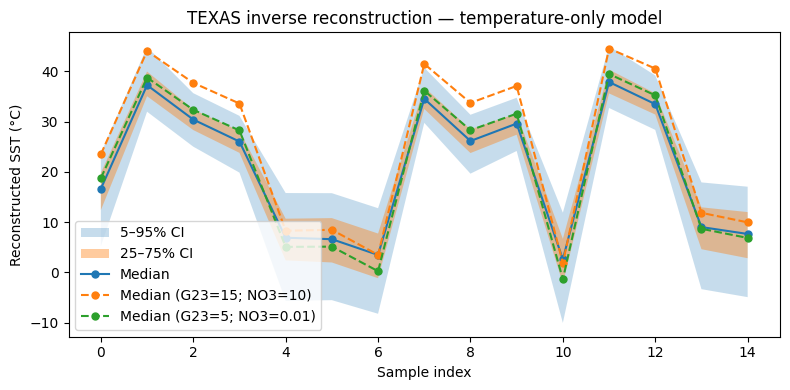

In [17]:
# ── Plot results ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
idx = np.arange(n)
ax.fill_between(idx, result["p5"], result["p95"], alpha=0.25, label="5–95% CI")
ax.fill_between(idx, result["p25"], result["p75"], alpha=0.4, label="25–75% CI")
ax.plot(idx, result["p50"], "o-", ms=5, lw=1.5, label="Median")

ax.plot(idx, result2["p50"], "o--", ms=5, lw=1.5, label="Median (G23=15; NO3=10)")
ax.plot(idx, result3["p50"], "o--", ms=5, lw=1.5, label="Median (G23=5; NO3=0.01)")

ax.set_xlabel("Sample index")
ax.set_ylabel("Reconstructed SST (°C)")
ax.set_title("TEXAS inverse reconstruction — temperature-only model")


ax.legend()
plt.tight_layout()
plt.show()

#### Example 1c: NO3 from real-world coordinates (no manual preprocessing)

Instead of supplying `no3=` directly (as above), pass `site_lat`/`site_lon` for your site(s) and TEXAS looks up the modern NO<sub>3</sub> climatology automatically. On first use it downloads and caches the WOA23-derived `ocean_prop_ds` field (~20 MB) from Zenodo — the same field previously only available by running the SI preprocessing notebook yourself. After that, it's read from the local cache.

In [18]:
# ── Run inverse reconstruction, NO3 looked up from coordinates ─────────────────
# `no3_dataset` is left unset: TEXAS downloads/caches the WOA23-derived
# ocean_prop_ds field from Zenodo automatically (one-time, ~20 MB) and looks
# up the modern NO3 climatology at (site_lat, site_lon) via bilinear interpolation.
result4 = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 15.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 10.0,    # prior uncertainty (°C) — use ~10 when uncertain
    gdgt23ratio    = gdgt23ratio_obs,
    site_lat       = 0.0,     # equatorial Pacific example — replace with your site's lat/lon
    site_lon       = -140.0,
)

📚 No fwd_posterior given — using the default SST calibration 'tx.GHEB.sst.sri03.G23-N1p0' (full multivariate, G23 + NO3).
  → saved to /home/rrattan/Documents/GitHub/TEXAS/data/spreadsheets/ds06_calculated_ocean_properties.nc
🌊 no3_dataset not provided — downloaded/cached the WOA23 ocean_prop_ds field from Zenodo.
🌊 WOA23 NO₃ lookup: lat=0.0, lon=-140.0 → 8.31 µmol/L


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/data/builder.py:211: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_available = post.dims[draw_dim_name]
/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:481: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
18:28:53 - cmdstanpy - INFO - compiling stan file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan to exe file /home/rrattan/.texas/stan_cache/invT_g

⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=15
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
   (build dir: /home/rrattan/.texas/stan_cache)


18:29:00 - cmdstanpy - INFO - compiled model executable: /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift
18:29:00 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
Starting Stan sampling with 15 observations...


...

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

18:29:14 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


If you're reconstructing many sites, or want to avoid a download inside every `predict_T_from_proxyObs()` call, fetch `ocean_prop_ds` once with `get_ocean_prop_ds()` and pass it in explicitly via `no3_dataset=`:

In [19]:
from TEXAS import get_ocean_prop_ds

# Downloads once (skipped if already cached) and returns an opened xr.Dataset.
ocean_prop_ds = get_ocean_prop_ds()

result5 = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 15.0,
    prior_sigma_t  = 10.0,
    gdgt23ratio    = gdgt23ratio_obs,
    site_lat       = 0.0,
    site_lon       = -140.0,
    no3_dataset    = ocean_prop_ds,   # reuse instead of re-downloading each call
)

Already cached: ds06_calculated_ocean_properties.nc
📚 No fwd_posterior given — using the default SST calibration 'tx.GHEB.sst.sri03.G23-N1p0' (full multivariate, G23 + NO3).
🌊 WOA23 NO₃ lookup: lat=0.0, lon=-140.0 → 8.31 µmol/L


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/data/builder.py:211: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_available = post.dims[draw_dim_name]
/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:481: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
18:29:15 - cmdstanpy - INFO - compiling stan file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan to exe file /home/rrattan/.texas/stan_cache/invT_g

⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=15
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
   (build dir: /home/rrattan/.texas/stan_cache)


18:29:23 - cmdstanpy - INFO - compiled model executable: /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift
18:29:23 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
Starting Stan sampling with 15 observations...


...

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

18:29:36 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


## Step 5b: Let's try with published paleo-records

In this example, we will use a PhanSST global compilation of paleoclimate proxies by [Judd et al. (2022)](https://doi.org/10.1038/s41597-022-01826-0) --- which also have TEX86!

We will read in the data using Pandas function `pd.read_csv()` which can take a url from the [NCEI Paleo Database](https://www.ncei.noaa.gov/access/paleo-search/study/36813).

In [20]:
url = 'https://www.ncei.noaa.gov/pub/data/paleo/paleocean/global/judd2022/phanSST-database.txt'

### we can read
PhanSST_df = pd.read_csv(url, sep='\t', na_values='NA', comment='#', low_memory=False, header=1)

print(PhanSST_df.shape)
print(PhanSST_df.columns.tolist())
print(PhanSST_df.head(3))

(149354, 55)
['SampleID', 'SiteName', 'SiteHole', 'MBSF', 'MCD', 'SampleDepth', 'Formation', 'Country', 'ContinentOcean', 'ModLat', 'ModLon', 'Age', 'Period', 'Stage', 'StagePosition', 'Biozone', 'AgeFlag', 'ProxyValue', 'ProxyType', 'ValueType', 'DiagenesisFlag', 'Taxon1', 'Taxon2', 'Taxon3', 'Environment', 'Ecology', 'AnalyticalTechnique', 'CL', 'Mn', 'Fe', 'Sr', 'Mg', 'Ca', 'Cawtp', 'MgCa', 'SrCa', 'MnSr', 'NBS120c', 'Durango', 'MaximumCAI', 'ModWaterDepth', 'CleaningMethod', 'GDGT0', 'GDGT1', 'GDGT2', 'GDGT3', 'Cren', 'Crenisomer', 'BIT', 'dRI', 'MI', 'LeadAuthor', 'Year', 'PublicationDOI', 'DataDOI']
  SampleID    SiteName SiteHole  MBSF  MCD  SampleDepth Formation Country  \
0      NaN  Alamedilla      NaN   NaN  NaN          NaN       NaN   Spain   
1      NaN  Alamedilla      NaN   NaN  NaN          NaN       NaN   Spain   
2      NaN  Alamedilla      NaN   NaN  NaN          NaN       NaN   Spain   

  ContinentOcean  ModLat  ...  GDGT3  Cren Crenisomer BIT dRI  MI  LeadAuthor 

We then filter only ProxyType == 'tex' to get only TEX86 data from the PhanSST database

In [21]:
PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType'] == 'tex'].reset_index(drop=True)

numeric_cols = ['MBSF', 'MCD', 'SampleDepth', 'ModLat', 'ModLon', 'Age', 'ProxyValue',
                'GDGT0', 'GDGT1', 'GDGT2', 'GDGT3', 'Cren', 'Crenisomer',
                'BIT', 'dRI', 'MI', 'Year']
for col in numeric_cols:
    PhanTEX_df[col] = pd.to_numeric(PhanTEX_df[col], errors='coerce')

print(PhanTEX_df.shape)
print(PhanTEX_df['ProxyValue'].describe())

(14091, 55)
count    14091.000000
mean         0.633294
std          0.123508
min          0.261827
25%          0.558233
50%          0.643000
75%          0.704567
max          0.981431
Name: ProxyValue, dtype: float64


In [22]:
from TEXAS import compute_scaledRI
PETM_df = PhanTEX_df[PhanTEX_df['SiteName'].isin(['ODP959'])].reset_index(drop=True)
PETM_df['scaledRI_cren3'] = compute_scaledRI(PETM_df['GDGT0'], PETM_df['GDGT1'], PETM_df['GDGT2'],PETM_df['GDGT3'], PETM_df['Cren'], PETM_df['Crenisomer'])                           
PETM_df['gdgt23ratio'] = PETM_df['GDGT2']/PETM_df['GDGT3']
PETM_df = PETM_df[PETM_df['MBSF'].between(801,806)].dropna(how='any',subset=['scaledRI_cren3']).reset_index(drop=True)

### Screen proxy data with Mahalanobis distance

Before running the inverse reconstruction, flag samples that fall outside the modern coretop calibration domain using Mahalanobis distance screening.

We fit `MahalanobisOutlierDetector` on the **screened coretop training data**, restricted to samples with `gdgt23ratio ≤ 5` (low-G23 subset). Features are `TEX86` and `scaledRI_cren3` — the same pair used in model development (SI_code3). Paleo samples outside the 90% confidence ellipse are flagged as outliers; `detect_outliers_manual()` additionally retains high-RI / high-TEX86 warm end-member samples even if they lie outside the ellipse.

In [23]:
import TEXAS
import pandas as pd
from TEXAS.utils.paths import SPREADSHEETS_DIR
from TEXAS.data import MahalanobisOutlierDetector

# Download screened coretop data from Zenodo (skipped if already cached)
TEXAS.download_training_data()

# Load the gridded coretop dataset used for calibration
combined_df = pd.read_csv(
    SPREADSHEETS_DIR / 'combined_coretop_culture_mesocosm_rev20260210.csv'
)
coretop_df = combined_df[combined_df['datatype']=='coretop']
# Fit on low-G23 coretops (gdgt23ratio ≤ 5 filters ecology-dominated sites)
detector = MahalanobisOutlierDetector(['TEX86', 'scaledRI_cren3'], confidence=0.9)
detector.fit(coretop_df[coretop_df['gdgt23ratio'] <= 5])
print(f"Fitted on {int((coretop_df['gdgt23ratio'] <= 5).sum())} coretop samples (gdgt23ratio ≤ 5)")
print(f"Mahalanobis threshold (90% CI): {detector.threshold:.3f}")

All training data files already present.
Fitted on 1205 coretop samples (gdgt23ratio ≤ 5)
Mahalanobis threshold (90% CI): 2.146


Screened out: 0 / 40 PETM samples


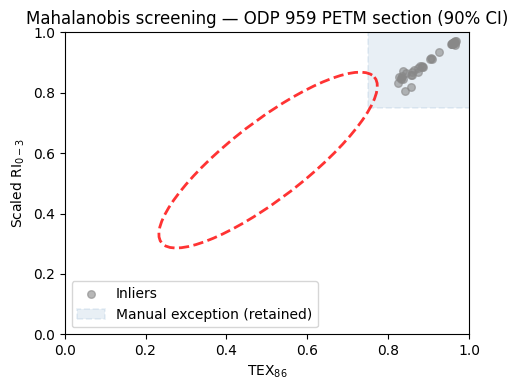

Samples passing screening: 40


In [24]:
import matplotlib.pyplot as plt                                                                                                                                
                                                                                                                                                                   
# TEX86 alias — ProxyValue column in the PhanSST database                                                                                                        
PETM_df['TEX86'] = PETM_df['ProxyValue']                                                                                                                         
                                                                                                                                                                
# Screen: flag paleo samples outside the coretop calibration domain                                                                                              
PETM_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'] = detector.detect_outliers_manual(PETM_df)                                                                                                                     
                                                                                                                                                                
n_out = int(PETM_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'].sum())                                                                                 
print(f"Screened out: {n_out} / {len(PETM_df)} PETM samples")                                                                                                    
                                                                                                                                                                
# Visualise                                                                                                                                                      
fig, ax = plt.subplots(figsize=(5, 4))                                                                                                                         
detector.plot_decision_boundary(PETM_df, ax=ax)
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xlabel("TEX$_{86}$")                                                                                                                                      
ax.set_ylabel(r"Scaled RI$_{0-3}$")
ax.set_title("Mahalanobis screening — ODP 959 PETM section (90% CI)")                                                                                            
plt.tight_layout()                                                                                                                                               
plt.show()                                                                                                                                                       
                                                                                                                                                                
# Keep only inliers                                                                                                                                              
PETM_df = PETM_df[                                                                                                                                             
    PETM_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'] == False
].reset_index(drop=True)                                                
print(f"Samples passing screening: {len(PETM_df)}")     

In [25]:
# Keep only inliers for temperature reconstruction
PETM_df = PETM_df[
    PETM_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'] == False
].reset_index(drop=True)
print(f"Samples passing screening: {len(PETM_df)}")

Samples passing screening: 40


In [26]:
from TEXAS import predict_T_from_proxyObs

np.random.seed(42)
n = 10
scaledRI_obs = PETM_df['scaledRI_cren3']
gdgt23ratio_obs = PETM_df['gdgt23ratio']

# ── Run inverse reconstruction ─────────────────────────────────────────────────
# The default calibration (tx.GHEB.sst.sri03.G23-N1p0) is the SST multivariate
# one used for the case studies, so nothing needs to be named here.
result_PETM_sigmaT10 = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 35.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 10.0,    # prior uncertainty (°C) — use ~10 when uncertain
    gdgt23ratio    = gdgt23ratio_obs,
    no3            = 10,      # Put no3=10 to ignore the nutrient effect
)

📚 No fwd_posterior given — using the default SST calibration 'tx.GHEB.sst.sri03.G23-N1p0' (full multivariate, G23 + NO3).


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/data/builder.py:211: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_available = post.dims[draw_dim_name]
/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:481: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
18:29:46 - cmdstanpy - INFO - compiling stan file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan to exe file /home/rrattan/.texas/stan_cache/invT_g

⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=40
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
   (build dir: /home/rrattan/.texas/stan_cache)


18:29:54 - cmdstanpy - INFO - compiled model executable: /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift
18:29:54 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
Starting Stan sampling with 40 observations...


...

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

18:30:55 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


In [27]:
## OPTIONAL: Sigma T = 15

result_PETM_sigmaT15 = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 35.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 15.0,    # prior uncertainty (°C) — use ~10 when uncertain
    gdgt23ratio    = gdgt23ratio_obs,
    no3            = 10,        # Put no3=10 to ignore the nutrient effect
    temptype       = "SST"
)

📚 No fwd_posterior given — using the default SST calibration 'tx.GHEB.sst.sri03.G23-N1p0' (full multivariate, G23 + NO3).


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/data/builder.py:211: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_available = post.dims[draw_dim_name]
/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:481: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
18:30:56 - cmdstanpy - INFO - compiling stan file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan to exe file /home/rrattan/.texas/stan_cache/invT_g

⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=40
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
   (build dir: /home/rrattan/.texas/stan_cache)


18:31:04 - cmdstanpy - INFO - compiled model executable: /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift
18:31:04 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
Starting Stan sampling with 40 observations...


...

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

18:32:20 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


In [28]:
## OPTIONAL: Sigma T = 20

result_PETM_sigmaT20 = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 35.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 20.0,    # prior uncertainty (°C) — use ~10 when uncertain
    gdgt23ratio    = gdgt23ratio_obs,
    no3            = 10,        # Put no3=10 to ignore the nutrient effect
    temptype       = "SST"
)

📚 No fwd_posterior given — using the default SST calibration 'tx.GHEB.sst.sri03.G23-N1p0' (full multivariate, G23 + NO3).


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/data/builder.py:211: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_available = post.dims[draw_dim_name]
/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:481: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
18:32:21 - cmdstanpy - INFO - compiling stan file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan to exe file /home/rrattan/.texas/stan_cache/invT_g

⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=40
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
   (build dir: /home/rrattan/.texas/stan_cache)


18:32:29 - cmdstanpy - INFO - compiled model executable: /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift
18:32:29 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
Starting Stan sampling with 40 observations...


...

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

18:34:21 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


In [29]:
# ── Run inverse reconstruction ─────────────────────────────────────────────────
# The default calibration (tx.GHEB.sst.sri03.G23-N1p0) is the SST multivariate
# one used for the case studies, so nothing needs to be named here.
result_PETM_sigmaT10_N0p1 = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 35.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 10.0,    # prior uncertainty (°C) — use ~10 when uncertain
    gdgt23ratio    = gdgt23ratio_obs,
    no3            = 0.1,      # Put no3=10 to ignore the nutrient effect
)

📚 No fwd_posterior given — using the default SST calibration 'tx.GHEB.sst.sri03.G23-N1p0' (full multivariate, G23 + NO3).


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/data/builder.py:211: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_available = post.dims[draw_dim_name]
/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:481: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
18:34:21 - cmdstanpy - INFO - compiling stan file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan to exe file /home/rrattan/.texas/stan_cache/invT_g

⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=40
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
   (build dir: /home/rrattan/.texas/stan_cache)


18:34:30 - cmdstanpy - INFO - compiled model executable: /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift
18:34:30 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
Starting Stan sampling with 40 observations...


...

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

18:35:43 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


In [30]:
## OPTIONAL: Sigma T = 15

result_PETM_sigmaT15_N0p1 = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 35.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 15.0,    # prior uncertainty (°C) — use ~10 when uncertain
    gdgt23ratio    = gdgt23ratio_obs,
    no3            = 0.1,        # Put no3=10 to ignore the nutrient effect
    temptype       = "SST"
)

📚 No fwd_posterior given — using the default SST calibration 'tx.GHEB.sst.sri03.G23-N1p0' (full multivariate, G23 + NO3).


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/data/builder.py:211: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_available = post.dims[draw_dim_name]
/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:481: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
18:35:44 - cmdstanpy - INFO - compiling stan file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan to exe file /home/rrattan/.texas/stan_cache/invT_g

⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=40
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
   (build dir: /home/rrattan/.texas/stan_cache)


18:35:52 - cmdstanpy - INFO - compiled model executable: /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift
18:35:52 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
Starting Stan sampling with 40 observations...


...

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

18:37:48 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


In [31]:
## OPTIONAL: Sigma T = 20

result_PETM_sigmaT20_N0p1 = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 35.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 20.0,    # prior uncertainty (°C) — use ~10 when uncertain
    gdgt23ratio    = gdgt23ratio_obs,
    no3            = 0.1,        # Put no3=10 to ignore the nutrient effect
    temptype       = "SST"
)

📚 No fwd_posterior given — using the default SST calibration 'tx.GHEB.sst.sri03.G23-N1p0' (full multivariate, G23 + NO3).


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/data/builder.py:211: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_available = post.dims[draw_dim_name]
/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:481: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
18:37:49 - cmdstanpy - INFO - compiling stan file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan to exe file /home/rrattan/.texas/stan_cache/invT_g

⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=40
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
   (build dir: /home/rrattan/.texas/stan_cache)


18:37:57 - cmdstanpy - INFO - compiled model executable: /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift
18:37:57 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
Starting Stan sampling with 40 observations...


...

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

18:40:15 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


NameError: name 'result_PETM' is not defined

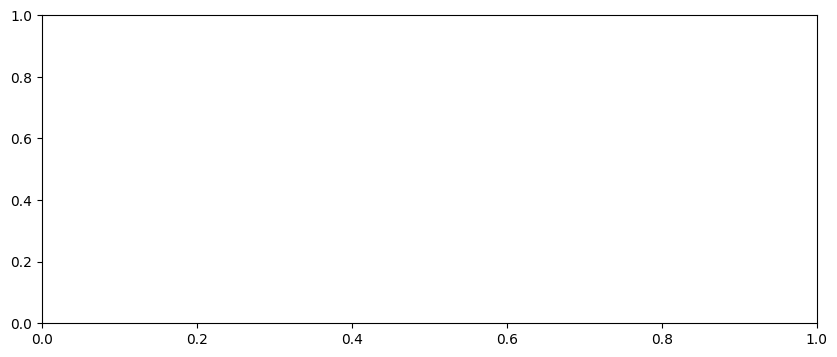

In [32]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm, ListedColormap

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(PETM_df['MBSF'].values, result_PETM['p50'], c='0.3', lw=1.5, zorder=5)

uncertainty_bands = [('p1','p99'), ('p5','p95'), ('p10','p90'), ('p16','p84'), ('p25','p75')]
labels = ['98% CI', '90% CI', '80% CI', '68% CI', '50% CI']

n = len(uncertainty_bands)
gray_colors = plt.get_cmap('Grays')(np.linspace(0.05, 0.45, n))
for i, band in enumerate(uncertainty_bands):
    ax.fill_between(PETM_df['MBSF'].values,
                    result_PETM[band[0]], result_PETM[band[1]],
                    color=gray_colors[i], linewidth=0)

ax.set_xlim(801, 806)

# Colorbar
cmap_cb = ListedColormap(gray_colors)
bounds = np.arange(n + 1)  # [0, 1, 2, 3, 4, 5]
norm_cb = BoundaryNorm(bounds, cmap_cb.N)

sm = mpl.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, ticks=np.arange(n) + 0.5)
cbar.set_ticklabels(labels)
cbar.set_label('Credible interval')

### Comparison with existing models

`texas-psm` provides `predict_tex86_from_sst` and `predict_tex_from_tex86` for commonly-used existing models

Users can select the existing model by passying `method=xxx` with xxx options are:
- `schouten2002` --- Original linear calibration [(Schouten et al., 2002)](https://doi.org/10.1016/S0012-821X(02)00979-2)
- `kim2010_tex86H` --- $\text{TEX}_{86}^{H}$ [(Kim et al., 2010)](https://doi.org/10.1016/S0012-821X(02)00979-2)

See `TEXAS.models.CalibrationRegistry` [API link here](https://paleolipidrr.github.io/TEXAS/api/#TEXAS.models.CalibrationRegistry)

`texas-psm` installation also requires `baysparpy` and `baysplinepy` so that we can reconstruct BAYSPAR temperatures for comparison
- see `baysparpy` documentation [here](https://baysparpy.readthedocs.io/en/stable/overview.html)
- see `baysplinepy` documentation [here](https://github.com/brews/baysplinepy)

In [ ]:
from TEXAS.models import predict_sst_from_tex86, predict_sst_from_tex86

PETM_df['SST_kim10_tex86h'] = predict_sst_from_tex86(PETM_df['ProxyValue'])
PETM_df['SST_schouten02'] = predict_sst_from_tex86(PETM_df['ProxyValue'],method='schouten02')

In [ ]:
import numpy as np
import bayspar as bsr

# ── Reading BAYSPAR results ───────────────────────────────────────────────────
# baysparpy 0.0.3's Prediction.percentile() calls np.percentile(interpolation=),
# a kwarg removed in numpy 2.0, so it raises on any current environment. This
# shim reproduces that method exactly using the modern `method=` argument, and
# is the same one the manuscript SI notebooks use.
def bayspar_percentile(pred, q=None, method='nearest'):
    """numpy-2-safe replacement for bayspar's Prediction.percentile().
    Returns an (n_obs, n_q) array: one row per observation, one column per q."""
    if q is None:
        q = [5, 50, 95]
    q = np.asarray(q, dtype=np.float64)
    axes = tuple(range(1, pred.ensemble.ndim))
    return np.percentile(pred.ensemble, q=q, axis=axes, method=method).T


result_bsr = bsr.predict_seatemp_analog(
    tex = PETM_df['ProxyValue'],
    prior_mean = 35,
    prior_std = 10,
    temptype = 'sst',
    search_tol = 0.25
)

# (n_obs, 3) — columns are p25, p50, p75
bsr_pct = bayspar_percentile(result_bsr, q=[16, 50, 84])

100%|██████████| 17/17 [00:15<00:00,  1.08it/s]


In [ ]:
## OPTIONAL: Sigma T = 20

result_bsr_sigmaT20 = bsr.predict_seatemp_analog(
    tex = PETM_df['ProxyValue'],
    prior_mean = 35,
    prior_std = 20,
    temptype = 'sst',
    search_tol = 0.25
)

bsr_pct_sigmaT20 = bayspar_percentile(result_bsr_sigmaT20, q=[16, 50, 84])

100%|██████████| 17/17 [00:15<00:00,  1.09it/s]


In [ ]:
## OPTIONAL: Sigma T = 15

result_bsr_sigmaT15 = bsr.predict_seatemp_analog(
    tex = PETM_df['ProxyValue'],
    prior_mean = 35,
    prior_std = 15,
    temptype = 'sst',
    search_tol = 0.25
)

bsr_pct_sigmaT15 = bayspar_percentile(result_bsr_sigmaT15, q=[16, 50, 84])

100%|██████████| 17/17 [00:15<00:00,  1.09it/s]


In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def attach_cbar(ax, sm=None, labels=None):
    """Append a fixed-width colorbar slot. If sm is None, reserve & hide it."""
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1)
    if sm is None:
        cax.axis("off")           # reserve the space but draw nothing
        return None
    cbar = fig.colorbar(sm, cax=cax, ticks=np.arange(n) + 0.5)
    cbar.set_ticklabels(labels)
    cbar.set_label('Credible interval')
    return cbar

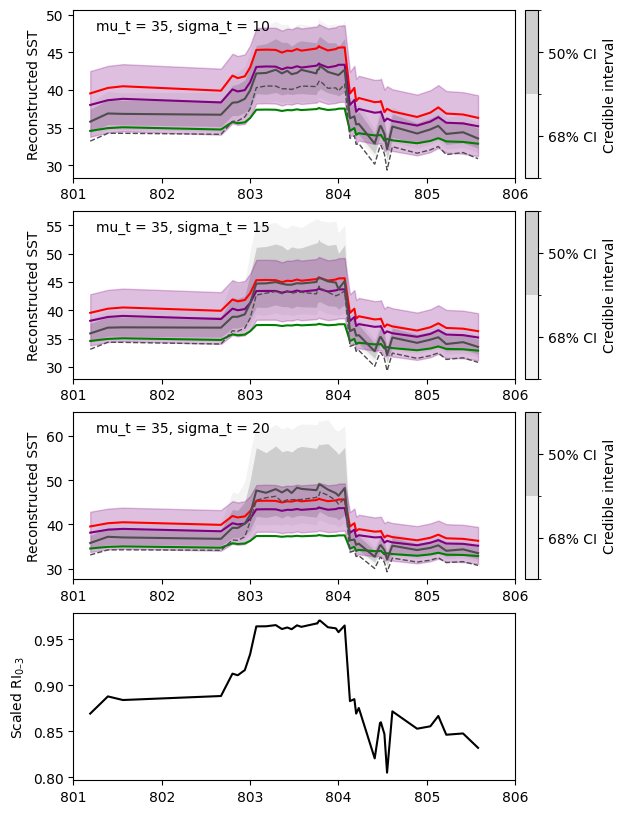

In [ ]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm, ListedColormap

fig, axs = plt.subplots(figsize=(6,10),nrows=4)

ax = axs[0]
ax.plot(PETM_df['MBSF'].values, result_PETM['p50'], c='0.3', lw=1.5, zorder=5)
ax.plot(PETM_df['MBSF'].values, result_PETM_sigmaT10_N0p1['p50'], c='0.3', lw=1, ls='--', zorder=5)

uncertainty_bands = [('p16','p84'), ('p25','p75')]
labels = ['68% CI', '50% CI']

n = len(uncertainty_bands)
gray_colors = plt.get_cmap('Grays')(np.linspace(0.1, 0.3, n))
for i, band in enumerate(uncertainty_bands):
    ax.fill_between(PETM_df['MBSF'].values,
                    result_PETM[band[0]], result_PETM[band[1]],
                    color=gray_colors[i], linewidth=0)

ax.set_xlim(801, 806)

# Colorbar
cmap_cb = ListedColormap(gray_colors)
bounds = np.arange(n + 1)  # [0, 1, 2, 3, 4, 5]
norm_cb = BoundaryNorm(bounds, cmap_cb.N)

sm = mpl.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
attach_cbar(ax, sm, labels)

########### add additional lines from existing models
ax.plot(PETM_df['MBSF'].values,PETM_df['SST_schouten02'].values,color='red')
ax.plot(PETM_df['MBSF'].values,PETM_df['SST_kim10_tex86h'].values,color='green')

#### bayspar

ax.plot(PETM_df['MBSF'].values, bsr_pct[:, 1], color='purple')
ax.fill_between(PETM_df['MBSF'].values, bsr_pct[:, 0], bsr_pct[:, 2], color='purple', alpha=0.25)
ax.set_ylabel("Reconstructed SST")
ax.text(0.05,0.95,
    "mu_t = 35, sigma_t = 10",
    transform=ax.transAxes,
    ha="left",va="top"
    )



############################################################
ax = axs[1]
ax.plot(PETM_df['MBSF'].values, result_PETM_sigmaT15['p50'], c='0.3', lw=1.5, zorder=5)
ax.plot(PETM_df['MBSF'].values, result_PETM_sigmaT15_N0p1['p50'], c='0.3', lw=1, ls='--', zorder=5)

uncertainty_bands = [('p16','p84'), ('p25','p75')]
labels = ['68% CI', '50% CI']

n = len(uncertainty_bands)
gray_colors = plt.get_cmap('Grays')(np.linspace(0.1, 0.3, n))
for i, band in enumerate(uncertainty_bands):
    ax.fill_between(PETM_df['MBSF'].values,
                    result_PETM_sigmaT15[band[0]], result_PETM_sigmaT15[band[1]],
                    color=gray_colors[i], linewidth=0)

ax.set_xlim(801, 806)

# Colorbar
attach_cbar(ax, sm, labels)

########### add additional lines from existing models
ax.plot(PETM_df['MBSF'].values,PETM_df['SST_schouten02'].values,color='red')
ax.plot(PETM_df['MBSF'].values,PETM_df['SST_kim10_tex86h'].values,color='green')

#### bayspar

ax.plot(PETM_df['MBSF'].values, bsr_pct_sigmaT15[:, 1], color='purple')
ax.fill_between(PETM_df['MBSF'].values, bsr_pct_sigmaT15[:, 0], bsr_pct_sigmaT15[:, 2], color='purple', alpha=0.25)
ax.set_ylabel("Reconstructed SST")
ax.text(0.05,0.95,
    "mu_t = 35, sigma_t = 15",
    transform=ax.transAxes,
    ha="left",va="top"
    )

############################################################
ax = axs[2]
ax.plot(PETM_df['MBSF'].values, result_PETM_sigmaT20['p50'], c='0.3', lw=1.5, zorder=5)
ax.plot(PETM_df['MBSF'].values, result_PETM_sigmaT20_N0p1['p50'], c='0.3', lw=1, ls='--', zorder=5)

uncertainty_bands = [('p16','p84'), ('p25','p75')]
labels = ['68% CI', '50% CI']

n = len(uncertainty_bands)
gray_colors = plt.get_cmap('Grays')(np.linspace(0.1, 0.3, n))
for i, band in enumerate(uncertainty_bands):
    ax.fill_between(PETM_df['MBSF'].values,
                    result_PETM_sigmaT20[band[0]], result_PETM_sigmaT20[band[1]],
                    color=gray_colors[i], linewidth=0)

ax.set_xlim(801, 806)

# Colorbar
attach_cbar(ax, sm, labels)

########### add additional lines from existing models
ax.plot(PETM_df['MBSF'].values,PETM_df['SST_schouten02'].values,color='red')
ax.plot(PETM_df['MBSF'].values,PETM_df['SST_kim10_tex86h'].values,color='green')

#### bayspar

ax.plot(PETM_df['MBSF'].values, bsr_pct_sigmaT20[:, 1], color='purple')
ax.fill_between(PETM_df['MBSF'].values, bsr_pct_sigmaT20[:, 0], bsr_pct_sigmaT20[:, 2], color='purple', alpha=0.25)
ax.set_ylabel("Reconstructed SST")
ax.text(0.05,0.95,
    "mu_t = 35, sigma_t = 20",
    transform=ax.transAxes,
    ha="left",va="top"
    )


############################################################
ax = axs[3]
ax.plot(PETM_df['MBSF'].values,PETM_df['scaledRI_cren3'].values,color='k')
ax.set_xlim(801, 806)
ax.set_ylabel(u"Scaled RI$_{0\u20133}$")
attach_cbar(ax)

---

## Step 6 — Save results

Save the reconstruction results back to Google Drive or download to your computer.

In [ ]:
# # ── Option A: save to Google Drive ────────────────────────────────────────────
# output_path = f"{DRIVE_BASE}/texas_results.csv"
# results_df.to_csv(output_path, index=False)
# print(f"Saved to {output_path}")

# # ── Option B: download to your computer ───────────────────────────────────────
# results_df.to_csv("texas_results.csv", index=False)
# from google.colab import files
# files.download("texas_results.csv")

---

## Notes

| | Colab (free) | Colab Pro | Local / Docker |
|---|---|---|---|
| Setup time | ~10 min first session | ~10 min first session | One-time ~15 min build |
| CmdStan persistence | ❌ Re-install each session | ✅ Longer runtime | ✅ Pre-built in image |
| Posterior persistence | ✅ Cache on Google Drive | ✅ Cache on Google Drive | ✅ Local `data/` folder |
| CPUs for Stan | 2 | 2–8 | As many as your machine |
| Recommended for | Exploration, sharing | Repeated invT runs | Full analysis |

**Caching posteriors on Google Drive**: set `TEXAS_CACHE_DIR` to a Drive path before importing TEXAS (see Step 3). The default calibration ships with the package and never needs downloading; anything you fetch from Zenodo is downloaded once and reused in later sessions.

**Using the multivariate model**: it is the default. If you have GDGT-2/3 ratio and NO₃ data, pass them and name no posterior:

```python
result = predict_T_from_proxyObs(
    proxyObs      = scaledRI_obs,
    prior_mu_t    = 15.0,
    prior_sigma_t = 10.0,
    gdgt23ratio   = my_g23_array,
    no3           = my_no3_array,   # or: no3=10.0 to disable NO₃ correction
)                                   # temptype="thermoT" for the thermocline calibration
```

**If you only have Scaled RI**: name the temperature-only calibration explicitly, `fwd_posterior="tx.GHPU.sst.sri03.p0"`. Passing no G23 to the default multivariate calibration is *not* the same thing — an omitted ratio is read as zero and biases the result cold, and the package warns when it happens.

**Citation**: Rattanasriampaipong et al. (in prep). *TEXAS: A proxy system model for TEX₈₆ paleothermometry.* AGU Paleoceanography and Paleoclimatology.